In [74]:
import numpy as np
import pandas as pd
import sklearn
import seaborn
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [75]:
df=pd.read_csv("/content/dataset.csv")

In [76]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                      

In [78]:
df.isna().sum()


,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance,0
Previous qualification,0
Nacionality,0
Mother's qualification,0
Father's qualification,0
Mother's occupation,0


In [79]:
df.duplicated().sum()


np.int64(0)

In [80]:
df.nunique()

,0
Marital status,6
Application mode,18
Application order,8
Course,17
Daytime/evening attendance,2
Previous qualification,17
Nacionality,21
Mother's qualification,29
Father's qualification,34
Mother's occupation,32


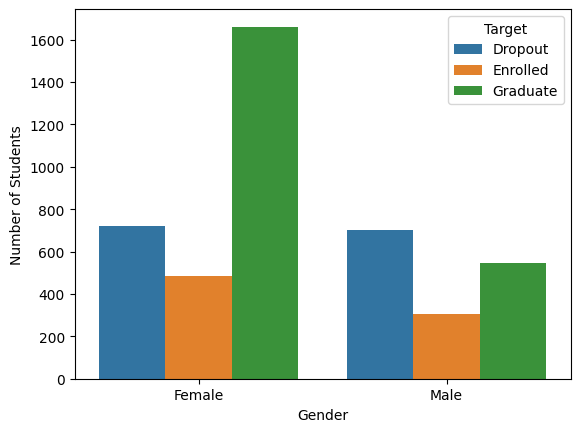

In [81]:
import seaborn as sns
sns.countplot(data=df, x='Gender', hue='Target', hue_order=['Dropout', 'Enrolled', 'Graduate'])
plt.xticks(ticks=[0,1], labels=['Female','Male'])
plt.ylabel('Number of Students')
plt.show()

# **feature engineering**

In [82]:
df_eng = df.copy()

# ── Academic performance features ────────────────────────────────
df_eng['Total_approved'] = (
    df_eng['Curricular units 1st sem (approved)'] +
    df_eng['Curricular units 2nd sem (approved)']
)
df_eng['Total_enrolled'] = (
    df_eng['Curricular units 1st sem (enrolled)'] +
    df_eng['Curricular units 2nd sem (enrolled)']
)
# Ratio of units approved vs enrolled (key predictor)
df_eng['Success_rate'] = df_eng['Total_approved'] / (df_eng['Total_enrolled'] + 1e-5)

# Average grade across both semesters
df_eng['Avg_grade'] = (
    df_eng['Curricular units 1st sem (grade)'] +
    df_eng['Curricular units 2nd sem (grade)']
) / 2

# Total evaluations taken
df_eng['Total_evaluations'] = (
    df_eng['Curricular units 1st sem (evaluations)'] +
    df_eng['Curricular units 2nd sem (evaluations)']
)

# Units failed (evaluations taken but not approved)
df_eng['Total_failed'] = np.maximum(
    df_eng['Total_evaluations'] - df_eng['Total_approved'], 0
)
df_eng['Fail_rate'] = df_eng['Total_failed'] / (df_eng['Total_evaluations'] + 1e-5)

# ── Semester improvement features ────────────────────────────────
df_eng['Grade_improvement'] = (
    df_eng['Curricular units 2nd sem (grade)'] -
    df_eng['Curricular units 1st sem (grade)']
)
df_eng['Approval_improvement'] = (
    df_eng['Curricular units 2nd sem (approved)'] -
    df_eng['Curricular units 1st sem (approved)']
)

# ── Financial & demographic ───────────────────────────────────────
df_eng['Financial_risk'] = (
    (df_eng['Debtor'] == 1) & (df_eng['Tuition fees up to date'] == 0)
).astype(int)

df_eng['Total_credited'] = (
    df_eng['Curricular units 1st sem (credited)'] +
    df_eng['Curricular units 2nd sem (credited)']
)

print('✓ Feature engineering complete')
print(f'New features added: Success_rate, Avg_grade, Total_evaluations, Total_failed,')
print(f'                    Fail_rate, Grade_improvement, Approval_improvement,')
print(f'                    Financial_risk, Total_credited')

✓ Feature engineering complete
New features added: Success_rate, Avg_grade, Total_evaluations, Total_failed,
                    Fail_rate, Grade_improvement, Approval_improvement,
                    Financial_risk, Total_credited


# **Drop Weak / Redundant Columns**

In [83]:
drop_cols = [
    # Low-predictive demographic
    'Nacionality', "Mother's qualification", "Father's qualification",
    'International', "Father's occupation", "Mother's occupation",
    'Educational special needs',
    # Raw cols replaced by engineered features
    'Curricular units 1st sem (approved)',  'Curricular units 2nd sem (approved)',
    'Curricular units 1st sem (enrolled)',  'Curricular units 2nd sem (enrolled)',
    'Curricular units 1st sem (grade)',     'Curricular units 2nd sem (grade)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 2nd sem (evaluations)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (without evaluations)',
    'Curricular units 1st sem (credited)',  'Curricular units 2nd sem (credited)',
]
df_eng = df_eng.drop(columns=[c for c in drop_cols if c in df_eng.columns])

print(f'Remaining features: {df_eng.shape[1] - 1}  (excl. Target)')
print(df_eng.drop(columns=['Target']).columns.tolist())

Remaining features: 26  (excl. Target)
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Displaced', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'Unemployment rate', 'Inflation rate', 'GDP', 'Total_approved', 'Total_enrolled', 'Success_rate', 'Avg_grade', 'Total_evaluations', 'Total_failed', 'Fail_rate', 'Grade_improvement', 'Approval_improvement', 'Financial_risk', 'Total_credited']


# **Outlier Removal (IQR)**

In [84]:
print(f'Before: {len(df_eng)} rows')

outlier_cols = ['Previous qualification', 'Age at enrollment']
for col in outlier_cols:
    if col in df_eng.columns:
        Q1 = df_eng[col].quantile(0.25)
        Q3 = df_eng[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        before = len(df_eng)
        df_eng = df_eng[(df_eng[col] >= lower) & (df_eng[col] <= upper)]
        print(f'  {col}: removed {before - len(df_eng)} outliers  (range: {lower:.1f}–{upper:.1f})')

print(f'After:  {len(df_eng)} rows')

Before: 4424 rows
  Previous qualification: removed 707 outliers  (range: 1.0–1.0)
  Age at enrollment: removed 469 outliers  (range: 12.0–28.0)
After:  3248 rows


In [85]:
df_eng.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Displaced,Debtor,Tuition fees up to date,Gender,...,Total_enrolled,Success_rate,Avg_grade,Total_evaluations,Total_failed,Fail_rate,Grade_improvement,Approval_improvement,Financial_risk,Total_credited
0,1,8,5,2,1,1,1,0,1,1,...,0,0.000000,0.000000,0,0,0.000000,0.000000,0,0,0
1,1,6,1,11,1,1,1,0,0,1,...,12,0.999999,13.833333,12,0,0.000000,-0.333333,0,0,0
2,1,1,5,5,1,1,1,0,0,1,...,12,0.000000,0.000000,0,0,0.000000,0.000000,0,0,0
3,1,8,2,15,1,1,1,0,1,0,...,12,0.916666,12.914286,18,7,0.388889,-1.028571,-1,0,0
6,1,1,1,12,1,1,1,0,1,0,...,15,0.999999,13.822500,17,2,0.117647,1.045000,1,0,0


In [86]:
# Show Target column distribution and preview
print("Target Value Counts:")
print(df_eng['Target'].value_counts())
print("\nFirst 10 values:")
print(df_eng[['Target']].head(10))

Target Value Counts:
Target
Graduate    1784
Dropout      834
Enrolled     630
Name: count, dtype: int64

First 10 values:
      Target
0    Dropout
1   Graduate
2    Dropout
3   Graduate
6   Graduate
7    Dropout
8   Graduate
9    Dropout
10  Graduate
11  Graduate


# label **encoding**

In [87]:
from sklearn.model_selection import train_test_split

# 1) First, encode the original 'Target' column from df_eng
label_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df_eng['Target_encoded'] = df_eng['Target'].map(label_map)

# 2) Filter dataset to keep only 'Dropout' (0) and 'Graduate' (2)
df_binary = df_eng[df_eng['Target_encoded'].isin([0, 2])].copy()

# 3) Map 'Graduate' (2) to 1 to make it binary (0 and 1)
df_binary['Target_encoded'] = df_binary['Target_encoded'].map({0: 0, 2: 1})

label_decode_bin = {0: 'Dropout', 1: 'Graduate'}

X_bin = df_binary.drop(['Target', 'Target_encoded'], axis=1, errors='ignore')
y_bin = df_binary['Target_encoded']

# 4) Split with binary target
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

print(f'Binary dataset size: {df_binary.shape[0]} samples')
print(f'Class balance (train):\n{y_train_bin.value_counts().rename(label_decode_bin)}')

Binary dataset size: 2618 samples
Class balance (train):
Target_encoded
Graduate    1427
Dropout      667
Name: count, dtype: int64


In [88]:
df_eng.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Displaced,Debtor,Tuition fees up to date,Gender,...,Success_rate,Avg_grade,Total_evaluations,Total_failed,Fail_rate,Grade_improvement,Approval_improvement,Financial_risk,Total_credited,Target_encoded
0,1,8,5,2,1,1,1,0,1,1,...,0.000000,0.000000,0,0,0.000000,0.000000,0,0,0,0
1,1,6,1,11,1,1,1,0,0,1,...,0.999999,13.833333,12,0,0.000000,-0.333333,0,0,0,2
2,1,1,5,5,1,1,1,0,0,1,...,0.000000,0.000000,0,0,0.000000,0.000000,0,0,0,0
3,1,8,2,15,1,1,1,0,1,0,...,0.916666,12.914286,18,7,0.388889,-1.028571,-1,0,0,2
6,1,1,1,12,1,1,1,0,1,0,...,0.999999,13.822500,17,2,0.117647,1.045000,1,0,0,2


# **Standardization**

In [89]:
from sklearn.preprocessing import StandardScaler

# Re-initialize and fit scaler on the binary training data
scaler_bin = StandardScaler()

X_train_scaled = scaler_bin.fit_transform(X_train_bin)
X_test_scaled = scaler_bin.transform(X_test_bin)

# Convert back to DataFrame for consistency
X_train = pd.DataFrame(X_train_scaled, columns=X_train_bin.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test_bin.columns)
y_train = y_train_bin.values
y_test = y_test_bin.values

print("Standardization complete for binary classification.")

Standardization complete for binary classification.


# **Split data into training and testing sets**


# Logistic **Regression**

In [90]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, zero_division=0))

Logistic Regression Accuracy: 0.8931297709923665
              precision    recall  f1-score   support

           0       0.91      0.74      0.81       167
           1       0.89      0.97      0.92       357

    accuracy                           0.89       524
   macro avg       0.90      0.85      0.87       524
weighted avg       0.89      0.89      0.89       524



In [91]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the Decision Tree
dt = DecisionTreeClassifier(random_state=10)
dt.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt.predict(X_test)

# Evaluate the model
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt, zero_division=0))

Decision Tree Accuracy: 0.8225190839694656
              precision    recall  f1-score   support

           0       0.72      0.72      0.72       167
           1       0.87      0.87      0.87       357

    accuracy                           0.82       524
   macro avg       0.80      0.80      0.80       524
weighted avg       0.82      0.82      0.82       524



In [92]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the SVM
svm = SVC(kernel='rbf', probability=True, random_state=10)
svm.fit(X_train, y_train)

# Make predictions
y_pred_svm = svm.predict(X_test)

# Evaluate the model
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm, zero_division=0))

SVM Accuracy: 0.8874045801526718
              precision    recall  f1-score   support

           0       0.92      0.71      0.80       167
           1       0.88      0.97      0.92       357

    accuracy                           0.89       524
   macro avg       0.90      0.84      0.86       524
weighted avg       0.89      0.89      0.88       524



In [93]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Make predictions
y_pred_knn = knn.predict(X_test)

# Evaluate the model
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn, zero_division=0))

KNN Accuracy: 0.8854961832061069
              precision    recall  f1-score   support

           0       0.91      0.71      0.80       167
           1       0.88      0.97      0.92       357

    accuracy                           0.89       524
   macro avg       0.89      0.84      0.86       524
weighted avg       0.89      0.89      0.88       524



In [94]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=10, n_jobs=-1)
rf.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf.predict(X_test)

# Evaluate the model
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, zero_division=0))

Random Forest Accuracy: 0.8874045801526718
              precision    recall  f1-score   support

           0       0.90      0.73      0.81       167
           1       0.88      0.96      0.92       357

    accuracy                           0.89       524
   macro avg       0.89      0.85      0.86       524
weighted avg       0.89      0.89      0.88       524



In [95]:
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1) Create and Fit Models
lr = LogisticRegression(max_iter=1000, random_state=10)
dt = DecisionTreeClassifier(random_state=10)
svm = SVC(kernel='rbf', probability=True, random_state=10)
knn = KNeighborsClassifier(n_neighbors=5)
rf = RandomForestClassifier(n_estimators=200, random_state=10, n_jobs=-1)
nb = GaussianNB()

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
svm.fit(X_train, y_train)
knn.fit(X_train, y_train)
rf.fit(X_train, y_train)
nb.fit(X_train, y_train)

# 2) Stacking Classifier
base_models = [
    ('lr', LogisticRegression(max_iter=1000, random_state=10)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=10)),
    ('svc', SVC(kernel='rbf', probability=True, random_state=10)),
    ('nb', GaussianNB()),
    ('dt', DecisionTreeClassifier(random_state=10)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
]

stacking = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=1000),
    passthrough=False,
    n_jobs=-1
)

stacking.fit(X_train, y_train)

# 3) Evaluate Models
models = {
    'LogisticRegression': lr,
    'DecisionTree': dt,
    'SVM_RBF': svm,
    'KNN': knn,
    'RandomForest': rf,
    'GaussianNB': nb,
    'StackingClassifier': stacking
}

results = []

# Use average='macro' for multiclass targets
for name, model in models.items():
    y_pred = model.predict(X_test)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'F1': f1_score(y_test, y_pred, average='macro', zero_division=0)
    })

results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
print(results_df)

                Model  Accuracy  Precision    Recall        F1
6  StackingClassifier  0.896947   0.901941  0.857445  0.874894
0  LogisticRegression  0.893130   0.899000  0.851457  0.869751
2             SVM_RBF  0.887405   0.896779  0.840881  0.861392
4        RandomForest  0.887405   0.890540  0.845662  0.863043
3                 KNN  0.885496   0.893130  0.839481  0.859329
5          GaussianNB  0.854962   0.837154  0.823446  0.829646
1        DecisionTree  0.822519   0.795512  0.796449  0.795977


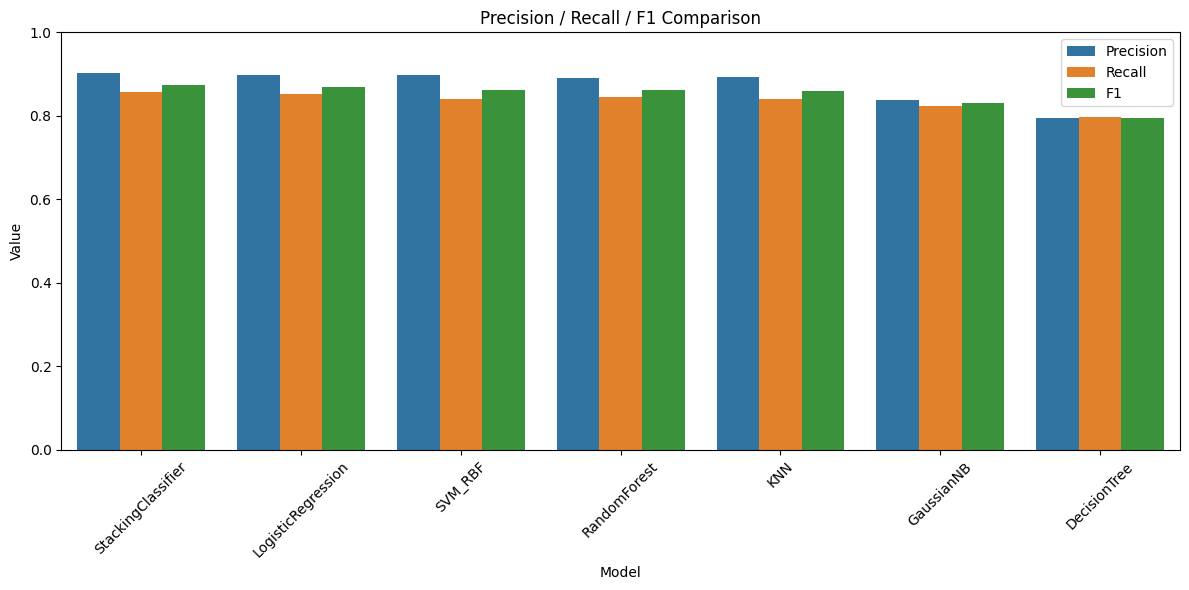

In [96]:
# Precision / Recall / F1 comparison
metrics_melt = results_df.melt(
    id_vars='Model',
    value_vars=['Precision','Recall','F1'],
    var_name='Metric',
    value_name='Value'
)

plt.figure(figsize=(12,6))
sns.barplot(data=metrics_melt, x='Model', y='Value', hue='Metric')
plt.ylim(0,1)
plt.xticks(rotation=45)
plt.title('Precision / Recall / F1 Comparison')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [101]:
import joblib

# Based on the results_df, SVM_RBF had the highest accuracy (0.7507)
best_model = svm

# Save the model to a file
joblib.dump(best_model, 'best_model.pkl')

print("Best model (SVM_RBF) has been saved as 'best_model.pkl'.")

Best model (SVM_RBF) has been saved as 'best_model.pkl'.


In [102]:
# Save the fitted scaler to a pkl file
joblib.dump(scaler, 'scaler.pkl')

print("Scaler has been saved as 'scaler.pkl'.")

Scaler has been saved as 'scaler.pkl'.


In [103]:
# Get the feature names from the training set
feature_names = X_train.columns.tolist()

# Save feature names to a pkl file
joblib.dump(feature_names, 'features.pkl')

print("Feature names have been saved as 'features.pkl'.")
print(f"Saved features: {feature_names}")

Feature names have been saved as 'features.pkl'.
Saved features: ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Displaced', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'Unemployment rate', 'Inflation rate', 'GDP', 'Total_approved', 'Total_enrolled', 'Success_rate', 'Avg_grade', 'Total_evaluations', 'Total_failed', 'Fail_rate', 'Grade_improvement', 'Approval_improvement', 'Financial_risk', 'Total_credited']
